In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset
import torchvision
from torch.utils.tensorboard import SummaryWriter
import jammy_flows
import os
from scipy.stats import norm


torchdiffeq not found - no support for continuous flows. Install *torchdiffeq* if support is desired!
Meander not installed... contours can not be calculated.
Healpy not installed... spherical contours can not be calculated.
package *astropy* not found -> if you want to use plotting functionality for adaptive grids, install *astropy*!
package *mhealpy* not found -> if you want to use plotting functionality for adaptive grids, install *mhealpy*!
Cannot use healpy functionality. Install healpy, if you need to do entropy scanning!


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")


Using device: cuda


In [ ]:
import os

data_dir = r"C:\Users\J Birbou\ML_Class\HW2"
spectra = np.load(os.path.join(data_dir, "spectra.npy"))
spectra_length = spectra.shape[1]
# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load(os.path.join(data_dir, "labels.npy"))
# We only use the three labels: t_eff, log_g, fe_h
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
n_labels = labels.shape[1]
spectra = np.log(np.maximum(spectra, 0.2))

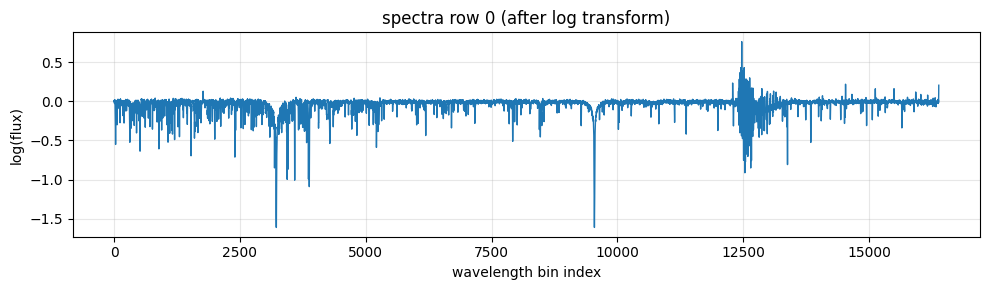

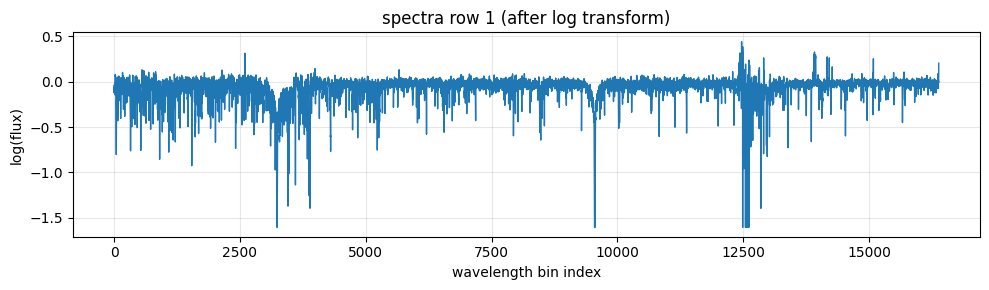

In [4]:
import matplotlib.pyplot as plt

for i in range(2):  # first 2 rows
    plt.figure(figsize=(10, 3))
    plt.plot(spectra[i], lw=1)
    plt.title(f"spectra row {i} (after log transform)")
    plt.xlabel("wavelength bin index")
    plt.ylabel("log(flux)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [5]:
# Z-score normalize labels
labels_mean = labels.mean(axis=0)
labels_std = labels.std(axis=0)
labels = (labels - labels_mean) / labels_std

# Z-score normalize spectra
spectra_mean = spectra.mean(axis=0)
spectra_std = spectra.std(axis=0)
spectra = (spectra - spectra_mean) / spectra_std

# Convert to tensors
spectra_tensor = torch.from_numpy(spectra).float()
labels_tensor = torch.from_numpy(labels).float()

print(f"spectra_tensor dtype: {spectra_tensor.dtype}, shape: {spectra_tensor.shape}")
print(f"labels_tensor dtype: {labels_tensor.dtype}, shape: {labels_tensor.shape}")

# Move to device
spectra_tensor = spectra_tensor.to(device)
labels_tensor = labels_tensor.to(device)

print(f"spectra_tensor device: {spectra_tensor.device}")
print(f"labels_tensor device: {labels_tensor.device}")





spectra_tensor dtype: torch.float32, shape: torch.Size([8914, 16384])
labels_tensor dtype: torch.float32, shape: torch.Size([8914, 3])
spectra_tensor device: cuda:0
labels_tensor device: cuda:0


In [6]:
# Split data
num_samples = spectra_tensor.shape[0]
train_size = int(0.7 * num_samples)
val_size = int(0.15 * num_samples)
test_size = num_samples - train_size - val_size

# Use TensorDataset to create a dataset
train_dataset, val_dataset, test_dataset \
= random_split(TensorDataset(spectra_tensor, labels_tensor), [train_size, val_size, test_size])

# Create DataLoaders
batch_size = 64  # increased from 10 for better GPU utilization
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 6239, Val: 1337, Test: 1338


In [8]:
EPOCHS = 100
LEARNING_RATE = 0.0003
INPUT_SIZE = 16384

# MODIFICATION: Renamed SimpleCNN to SimpleCNNEncoder.
# Changed the initialization to accept 'latent_dimension' so it can dynamically 
# match the required number of parameters for the jammy_flows model.
class SimpleCNNEncoder(nn.Module):
    def __init__(self, latent_dimension):
        super(SimpleCNNEncoder, self).__init__()
        self.model = nn.Sequential(
            nn.Conv1d(1, 10, kernel_size=5), 
            nn.ReLU(), 
            nn.BatchNorm1d(10), 
            nn.Dropout(0.1), 
            nn.AvgPool1d(3),

            nn.Conv1d(10, 20, kernel_size=5), 
            nn.ReLU(), 
            nn.BatchNorm1d(20), 
            nn.Dropout(0.1), 
            nn.AvgPool1d(3),
            
            nn.Conv1d(20, 40, kernel_size=5), 
            nn.ReLU(), 
            nn.BatchNorm1d(40), 
            nn.Dropout(0.1), 
            nn.AvgPool1d(3),
            
            nn.Conv1d(40, 10, kernel_size=1), 
            nn.ReLU(), 
            nn.BatchNorm1d(10), 
            nn.Dropout(0.1), 
            nn.AvgPool1d(2),
            
            nn.Conv1d(10, 12, kernel_size=3), 
            nn.ReLU(), 
            nn.BatchNorm1d(12), 
            nn.Dropout(0.2),
            nn.Conv1d(12, 10, kernel_size=1), 
            nn.Dropout(0.2),
            
            nn.Linear(300, 32), 
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(10 * 32, 128),
            nn.ReLU(),
            # MODIFICATION: Changed hardcoded 6 to latent_dimension
            nn.Linear(128, latent_dimension)
        )

    def forward(self, x):
        x = torch.unsqueeze(x, 1)
        x = self.model(x)
        return x


In [ ]:
# MODIFICATION: Added the CombinedModel class from the template. combines the CNN encoder and the jammy_flows PDF
class CombinedModel(nn.Module):
    def __init__(self, encoder_class, nf_type="diagonal_gaussian"):
        super().__init__()
        opt_dict = {"t": {"cov_type": "diagonal"}}
        flow_defs = "t"
        #opt_dict["g"] = {"fit_normalization": 1, "upper_bound_for_widths": 1.0, "lower_bound_for_widths": 0.01}
        self.nf_type = nf_type

        # "e3" defines a 3-dimensional Euclidean space for the 3 labels
        self.pdf = jammy_flows.pdf("e3", flow_defs, options_overwrite=opt_dict,
                                   amortize_everything=True, amortization_mlp_use_custom_mode=True)

        num_flow_parameters = self.pdf.total_number_amortizable_params
        print("The normalizing flow has", num_flow_parameters, "parameters...")

        # Initialize the encoder to output exactly the number of required flow parameters
        self.encoder = encoder_class(num_flow_parameters)

    def log_pdf_evaluation(self, target_labels, input_data):
        latent_intermediate = self.encoder(input_data)
        log_pdf, _, _ = self.pdf(target_labels, amortization_parameters=latent_intermediate)
        return log_pdf

    def sample(self, flow_params, samplesize_per_batchitem=1000):
        batch_size = flow_params.shape[0]
        repeated_samples, _, _, _ = self.pdf.sample(amortization_parameters=flow_params.repeat_interleave(
            samplesize_per_batchitem, dim=0), allow_gradients=False)
        reshaped_samples = repeated_samples[:, None, :].view(batch_size, samplesize_per_batchitem, -1)
        return reshaped_samples

    def forward(self, input_data, samplesize_per_batchitem=1000):
        flow_params = self.encoder(input_data)
        samples = self.sample(flow_params, samplesize_per_batchitem=samplesize_per_batchitem)
        means = samples.mean(dim=1)
        std_deviations = samples.std(dim=1)
        return torch.cat([means, std_deviations], dim=1)

In [7]:
def nf_loss(inputs, batch_labels, model):
    log_pdfs = model.log_pdf_evaluation(batch_labels, inputs) 
    loss = -log_pdfs.mean() 
    return loss

In [10]:
# --- Initialization ---
# MODIFICATION: Instantiating the CombinedModel instead of just the CNN.
model = CombinedModel(SimpleCNNEncoder, nf_type="diagonal_gaussian").to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Parameters: {sum(p.numel() for p in model.parameters())}")

# --- Training Loop ---
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        # MODIFICATION: Compute loss directly using the inputs and targets with nf_loss
        loss = nf_loss(batch_x, batch_y, model)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            # MODIFICATION: Compute val loss directly using nf_loss
            loss = nf_loss(batch_x, batch_y, model)
            val_loss += loss.item()
            
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train NLL = {train_loss:.4f}, Val NLL = {val_loss:.4f}")

print("Training complete!")

sub-manifold (0 - e3 - t) and intra-manifold flow (0 - t) options overwrite  cov_type  with  diagonal
The normalizing flow has 6 parameters...
Parameters: 57710
Epoch 0: Train NLL = 3.2447, Val NLL = 1.9084
Epoch 10: Train NLL = -0.1471, Val NLL = -0.5003
Epoch 20: Train NLL = -0.5351, Val NLL = -0.9872
Epoch 30: Train NLL = -0.7957, Val NLL = -0.9621
Epoch 40: Train NLL = -0.9515, Val NLL = -1.1539
Epoch 50: Train NLL = -1.0670, Val NLL = -1.1327
Epoch 60: Train NLL = -1.1126, Val NLL = -1.2370
Epoch 70: Train NLL = -1.2513, Val NLL = -1.3107
Epoch 80: Train NLL = -1.3147, Val NLL = -1.1919
Epoch 90: Train NLL = -1.3931, Val NLL = -1.2345
Training complete!


In [12]:
# --- Evaluation Loop ---
model.eval()
test_loss = 0
all_means = []
all_stds = []
all_targets = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        # MODIFICATION: Use nf_loss for test loss evaluation
        loss = nf_loss(batch_x, batch_y, model)  
        test_loss += loss.item()

        # MODIFICATION: Calling the model now executes the forward() method of CombinedModel,
        # which samples the flow and returns [means, actual_stds] concatenated.
        predictions = model(batch_x)
        
        # MODIFICATION: We extract standard deviations directly now, no longer log_stds.
        all_means.append(predictions[:, :3].cpu())
        all_stds.append(predictions[:, 3:].cpu())
        all_targets.append(batch_y.cpu())

test_loss /= len(test_loader)
all_means = torch.cat(all_means)
all_stds = torch.cat(all_stds)
all_targets = torch.cat(all_targets)

# MODIFICATION: Removed the torch.exp() step since the flow returns standard deviations natively.
mae = torch.mean(torch.abs(all_means - all_targets)).item()

print(f"Final Test Loss (NLL): {test_loss:.4f}")
print(f"Mean Absolute Error (Z-Score Space): {mae:.4f}")

# --- Un-normalize to physical units ---
labels_mean_tensor = torch.tensor(labels_mean).float()
labels_std_tensor = torch.tensor(labels_std).float()

physical_means = (all_means * labels_std_tensor) + labels_mean_tensor
physical_targets = (all_targets * labels_std_tensor) + labels_mean_tensor
physical_stds = all_stds * labels_std_tensor


Final Test Loss (NLL): -1.3994
Mean Absolute Error (Z-Score Space): 0.1250


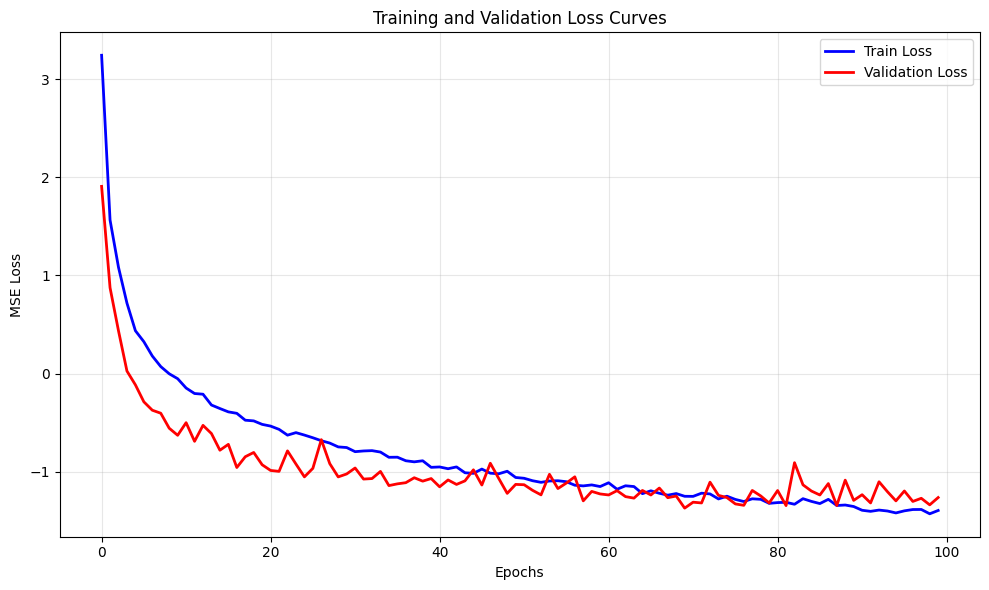

In [ ]:
# Plot training/validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Train Loss", color="blue", linewidth=2)
plt.plot(val_losses, label="Validation Loss", color="red", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plot0a.jpg", format='jpg', dpi=450)
plt.show()

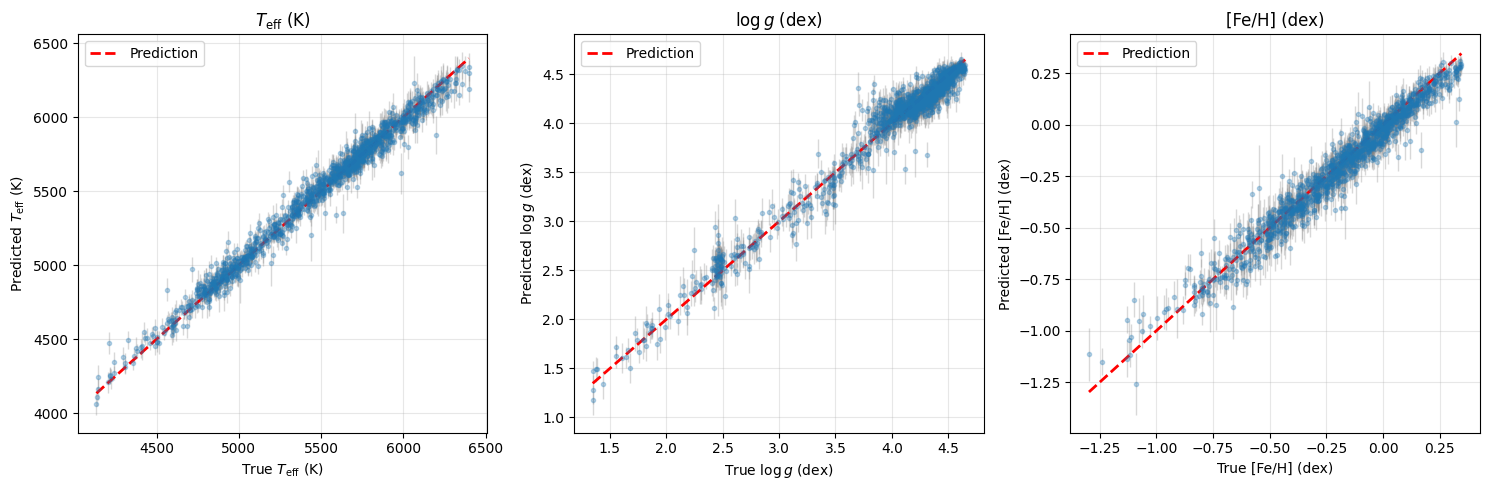

t_eff correlation: 0.9915
log_g correlation: 0.9851
fe_h correlation: 0.9788


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert the previously calculated physical tensors to NumPy arrays for Matplotlib
pred_denorm = physical_means.numpy()
true_denorm = physical_targets.numpy()
stds_denorm = physical_stds.numpy()

# Plot for each label
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Use standard astrophysical units for clarity
label_names = [r"$T_{\mathrm{eff}}$ (K)", r"$\log g$ (dex)", r"[Fe/H] (dex)"]

for i, (name, ax) in enumerate(zip(label_names, axes)):
    # Replace scatter with errorbar to visualize the predicted standard deviations
    ax.errorbar(true_denorm[:, i], pred_denorm[:, i], yerr=stds_denorm[:, i], 
                fmt='o', alpha=0.3, markersize=3, ecolor='gray', elinewidth=1, capsize=0)
    
    # Identity line
    min_val = true_denorm[:, i].min()
    max_val = true_denorm[:, i].max()
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prediction')
    
    ax.set_xlabel(f'True {name}')
    ax.set_ylabel(f'Predicted {name}')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plot1a.jpg", format='jpg', dpi=450)
plt.show()

# Print correlation coefficients
for i, name in enumerate(["t_eff", "log_g", "fe_h"]):
    corr = np.corrcoef(true_denorm[:, i], pred_denorm[:, i])[0, 1]
    print(f"{name} correlation: {corr:.4f}")

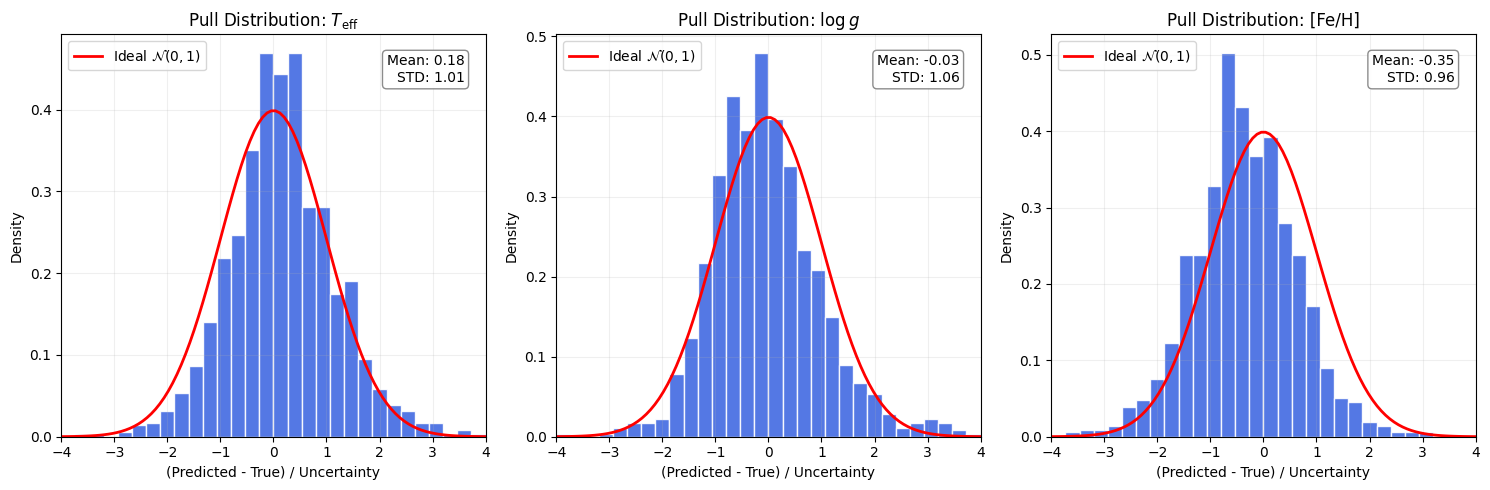

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Assuming pred_denorm, true_denorm, and stds_denorm are already in memory 
# from the previous evaluation script.

# Define the labels with LaTeX for clean formatting
label_names = [r"$T_{\mathrm{eff}}$", r"$\log g$", r"[Fe/H]"]

# Create a 1x3 subplot layout
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (name, ax) in enumerate(zip(label_names, axes)):
    
    # 1. Calculate the pull: (Predicted - True) / Uncertainty
    pull = (pred_denorm[:, i] - true_denorm[:, i]) / stds_denorm[:, i]
    
    # Calculate the empirical mean and standard deviation of the pull
    mu_pull = np.mean(pull)
    std_pull = np.std(pull)
    
    # 2. Plot the histogram
    # We use density=True so the area under the histogram equals 1, 
    # allowing us to directly overlay the theoretical probability curve.
    ax.hist(pull, bins=30, range=(-4, 4), density=True, 
            color='royalblue', edgecolor='white', alpha=0.9)
    
    # 3. Overlay the ideal Standard Normal Distribution
    x_axis = np.linspace(-4, 4, 100)
    ideal_pdf = norm.pdf(x_axis, loc=0, scale=1)
    ax.plot(x_axis, ideal_pdf, 'r-', linewidth=2, label=r'Ideal $\mathcal{N}(0,1)$')
    
    # 4. Add the statistics text box to match your reference image
    textstr = f'Mean: {mu_pull:.2f}\nSTD: {std_pull:.2f}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    ax.text(0.95, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right', bbox=props)
    
    # Formatting
    ax.set_xlabel('(Predicted - True) / Uncertainty')
    ax.set_ylabel('Density')
    ax.set_title(f'Pull Distribution: {name}')
    ax.set_xlim(-4, 4)
    ax.legend(loc='upper left')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("plot2a.jpg", format='jpg', dpi=450)
plt.show()